# Classificação de Qualidade de Vinhos

In [1]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

## Carga do Dataset

O dataset utilizado contém informações físico-químicas de vinhos tintos, onde cada linha representa uma amostra diferente. As variáveis cobrem aspectos como acidez fixa e volátil, pH, teor alcoólico e concentração de sulfatos. A coluna `quality` traz a nota de qualidade do vinho, que servirá de base para a classificação.

In [2]:
url = "https://raw.githubusercontent.com/cclguedes/Classificador_Vinhos_Backend/refs/heads/main/dataset/WineQT.csv"

dataset = pd.read_csv(url, delimiter=',')
dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Análise Inicial

Antes de qualquer modelagem, exploramos o dataset para entender com o que estamos trabalhando.

A função `info()` mostrou que o conjunto tem 1143 amostras e 13 colunas, todas numéricas. Nenhuma coluna apresentou valores ausentes, o que nos poupou qualquer trabalho de limpeza.

Com o `describe()`, observamos as distribuições de cada variável — médias, desvios e extremos — sem nada que indicasse inconsistências graves nos dados.

A ausência de nulos foi confirmada pelo `isnull().sum()`, encerrando a análise inicial com um dataset limpo e pronto para as próximas etapas.

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
dataset.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [5]:
dataset.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## Transformação do Problema

A coluna `quality` originalmente contém notas numéricas de 3 a 8. Como queremos resolver um problema de classificação, precisamos convertê-la em categorias.

Optamos por uma divisão binária simples: vinhos com nota até 5 foram classificados como **"ruim"**, e os demais como **"bom"**. Esse corte reflete uma distinção prática entre vinhos abaixo e acima da média.

Após aplicar a categorização, verificamos a distribuição das classes com `value_counts()`. O dataset apresenta mais amostras da classe "bom" do que "ruim", um leve desbalanceamento que vale observar durante a avaliação dos modelos.

Por fim, removemos a coluna `quality` original para que ela não interfira no treinamento do modelo.

In [6]:
def categorizar(q):
    if q <= 5:
        return "ruim"
    else:
        return "bom"

dataset["categoria"] = dataset["quality"].apply(categorizar)

# Distribuição das classes
print(dataset["categoria"].value_counts())
print()
print(dataset["categoria"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

categoria
bom     621
ruim    522
Name: count, dtype: int64

categoria
bom     54.3%
ruim    45.7%
Name: proportion, dtype: object


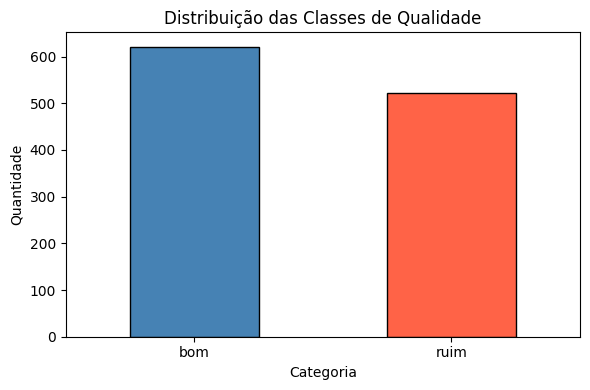

In [7]:
# Visualização da distribuição das classes
fig, ax = plt.subplots(figsize=(6, 4))
dataset["categoria"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="black")
ax.set_title("Distribuição das Classes de Qualidade")
ax.set_xlabel("Categoria")
ax.set_ylabel("Quantidade")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [8]:
dataset = dataset.drop(columns=["quality"])

## Separação das Variáveis

Aqui separamos o que o modelo vai usar como entrada (X) do que ele deve aprender a prever (y).

As features em X são as 11 características físico-químicas dos vinhos. Removemos também a coluna `Id`, que é apenas um identificador sem valor preditivo. A variável alvo y é a coluna `categoria`, com os rótulos "ruim" e "bom".

In [9]:
X = dataset.drop(columns=["categoria", "Id"])
y = dataset["categoria"]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (1143, 11)
Dimensão de y: (1143,)


## Separação em Conjunto de Treino e Teste

Dividimos os dados em treino (80%) e teste (20%) usando a técnica de holdout. A divisão foi feita de forma estratificada (`stratify=y`), o que garante que a proporção entre as classes seja mantida nos dois subconjuntos — importante dado o leve desbalanceamento observado.

Fixamos a semente aleatória em 7 para garantir que os resultados sejam reproduzíveis. Configuramos também o Stratified K-Fold com 10 partições para a etapa de validação cruzada.

In [10]:
test_size = 0.20
seed = 7

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=seed,
    stratify=y
)

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)
scoring = 'accuracy'

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste:  {X_test.shape[0]} amostras")

Tamanho do conjunto de treino: 914 amostras
Tamanho do conjunto de teste:  229 amostras


## Modelagem e Inferência

### Criação e avaliação de modelos: linha base

Testamos quatro algoritmos clássicos de classificação — **KNN**, **CART**, **Naive Bayes** e **SVM** — usando os dados originais, sem nenhuma transformação de escala. A avaliação foi feita por validação cruzada estratificada com 10 partições, usando acurácia como métrica.

KNN: 0.6619 (0.0552)
CART: 0.7220 (0.0674)
NB: 0.7221 (0.0651)
SVM: 0.6313 (0.0466)


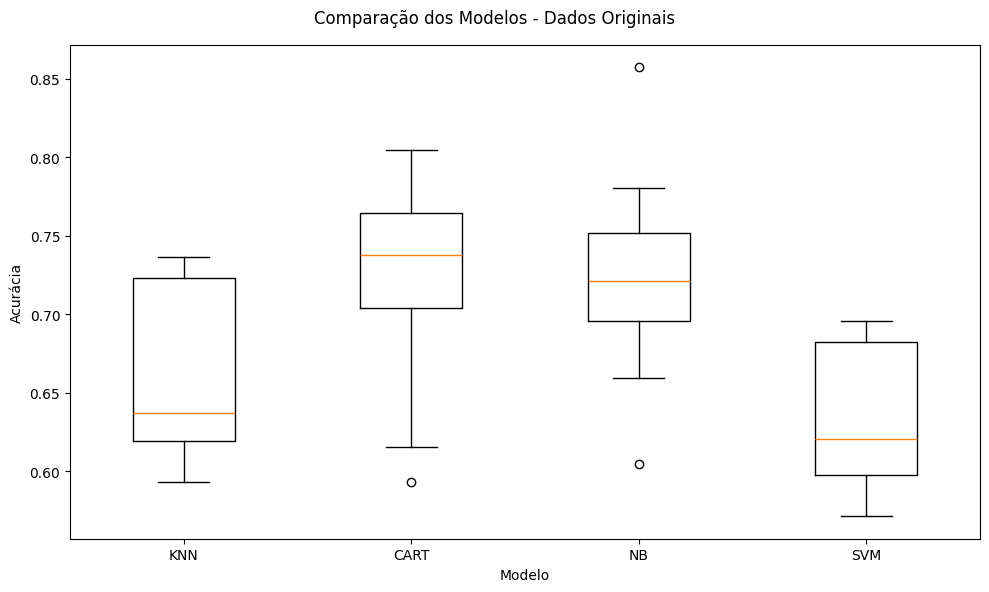

In [11]:
np.random.seed(seed)

models = []
models.append(("KNN",  KNeighborsClassifier()))
models.append(("CART", DecisionTreeClassifier()))
models.append(("NB",   GaussianNB()))
models.append(("SVM",  SVC()))

results = []
names = []

for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})")

# Boxplot
fig = plt.figure(figsize=(10, 6))
fig.suptitle('Comparação dos Modelos - Dados Originais')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
ax.set_ylabel("Acurácia")
ax.set_xlabel("Modelo")
plt.tight_layout()
plt.show()

### Criação e avaliação de modelos: dados padronizados e normalizados

Alguns algoritmos, como o SVM e o KNN, são sensíveis à escala das variáveis. Para avaliar o impacto da transformação dos dados, repetimos a comparação usando pipelines com **StandardScaler** (padronização) e **MinMaxScaler** (normalização).

O uso de pipelines garante que a transformação seja aplicada apenas aos dados de treino de cada fold, evitando vazamento de informação (data leakage).

KNN-padr: 0.7252 (0.0752)
CART-padr: 0.7187 (0.0641)
NB-padr: 0.7265 (0.0623)
SVM-padr: 0.7745 (0.0597)
KNN-norm: 0.7187 (0.0583)
CART-norm: 0.7089 (0.0601)
NB-norm: 0.7265 (0.0623)
SVM-norm: 0.7604 (0.0588)


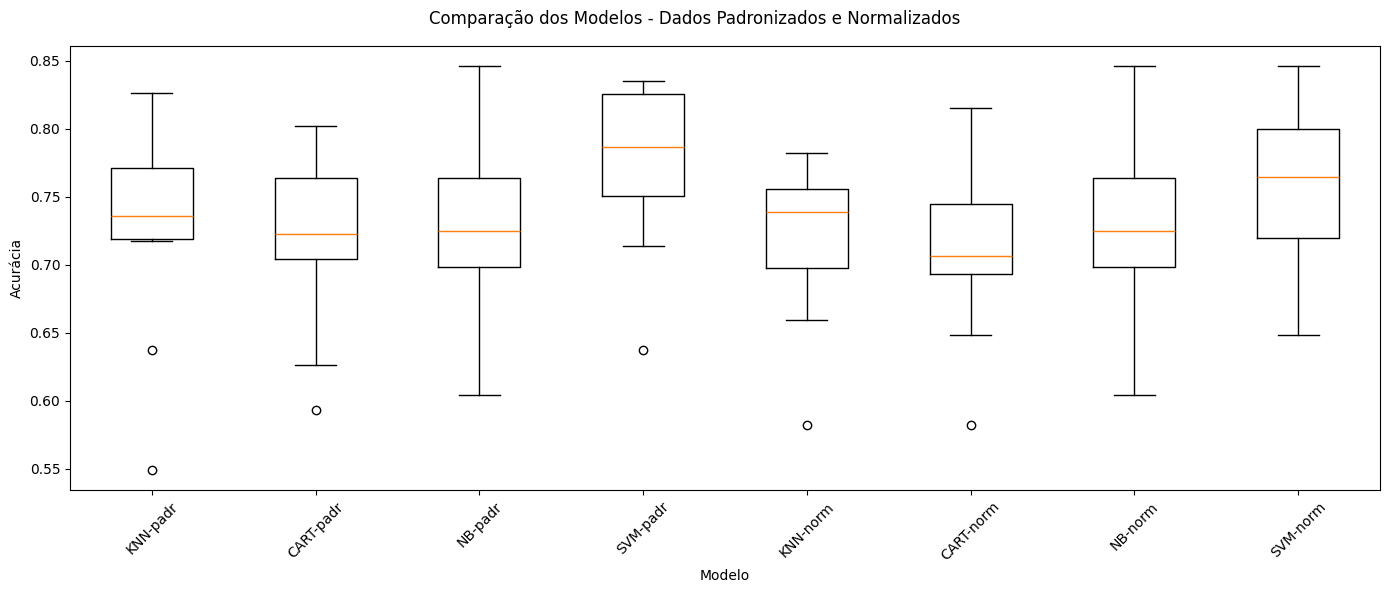

In [12]:
np.random.seed(seed)

pipelines = []
results_scaled = []
names_scaled = []

# Algoritmos
knn   = ('KNN',  KNeighborsClassifier())
cart  = ('CART', DecisionTreeClassifier())
nb    = ('NB',   GaussianNB())
svm   = ('SVM',  SVC())

# Scalers
std_scaler = ('StandardScaler', StandardScaler())
mm_scaler  = ('MinMaxScaler',   MinMaxScaler())

# Pipelines com dados padronizados
pipelines.append(('KNN-padr',  Pipeline([std_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([std_scaler, cart])))
pipelines.append(('NB-padr',   Pipeline([std_scaler, nb])))
pipelines.append(('SVM-padr',  Pipeline([std_scaler, svm])))

# Pipelines com dados normalizados
pipelines.append(('KNN-norm',  Pipeline([mm_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([mm_scaler, cart])))
pipelines.append(('NB-norm',   Pipeline([mm_scaler, nb])))
pipelines.append(('SVM-norm',  Pipeline([mm_scaler, svm])))

for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results_scaled.append(cv_results)
    names_scaled.append(name)
    print(f"{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})")

# Boxplot
fig = plt.figure(figsize=(14, 6))
fig.suptitle('Comparação dos Modelos - Dados Padronizados e Normalizados')
ax = fig.add_subplot(111)
plt.boxplot(results_scaled)
ax.set_xticklabels(names_scaled, rotation=45)
ax.set_ylabel("Acurácia")
ax.set_xlabel("Modelo")
plt.tight_layout()
plt.show()

### Otimização de Hiperparâmetros

Com os resultados da linha base e dos dados transformados em mãos, partimos para a otimização de hiperparâmetros usando **Grid Search** com validação cruzada. O objetivo é encontrar a combinação de parâmetros que maximiza a acurácia de cada modelo.

Testamos cada algoritmo nas três versões do dataset (original, padronizado e normalizado) para identificar a configuração ideal.

In [13]:
np.random.seed(seed)

# Grades de hiperparâmetros por algoritmo
param_grid_knn  = {'KNN__n_neighbors': [3, 5, 7, 9, 11], 'KNN__metric': ['euclidean', 'manhattan']}
param_grid_cart = {'CART__max_depth': [None, 5, 10, 20], 'CART__min_samples_split': [2, 5, 10]}
param_grid_nb   = {'NB__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]}
param_grid_svm  = {'SVM__C': [0.1, 1, 10, 100], 'SVM__kernel': ['linear', 'rbf']}

configs = [
    ('KNN-orig',  Pipeline([knn]),              param_grid_knn),
    ('KNN-padr',  Pipeline([std_scaler, knn]),  param_grid_knn),
    ('KNN-norm',  Pipeline([mm_scaler,  knn]),  param_grid_knn),
    ('CART-orig', Pipeline([cart]),             param_grid_cart),
    ('CART-padr', Pipeline([std_scaler, cart]), param_grid_cart),
    ('CART-norm', Pipeline([mm_scaler,  cart]), param_grid_cart),
    ('NB-orig',   Pipeline([nb]),               param_grid_nb),
    ('NB-padr',   Pipeline([std_scaler, nb]),   param_grid_nb),
    ('NB-norm',   Pipeline([mm_scaler,  nb]),   param_grid_nb),
    ('SVM-orig',  Pipeline([svm]),              param_grid_svm),
    ('SVM-padr',  Pipeline([std_scaler, svm]),  param_grid_svm),
    ('SVM-norm',  Pipeline([mm_scaler,  svm]),  param_grid_svm),
]

for name, pipeline, param_grid in configs:
    gs = GridSearchCV(pipeline, param_grid, cv=kfold, scoring=scoring)
    gs.fit(X_train, y_train)
    print(f"Modelo: {name} - Melhor: {gs.best_score_:.6f} usando {gs.best_params_}")

Modelo: KNN-orig - Melhor: 0.688139 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 11}
Modelo: KNN-padr - Melhor: 0.737339 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 9}
Modelo: KNN-norm - Melhor: 0.733003 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 11}
Modelo: CART-orig - Melhor: 0.727461 usando {'CART__max_depth': 20, 'CART__min_samples_split': 2}
Modelo: CART-padr - Melhor: 0.727592 usando {'CART__max_depth': 5, 'CART__min_samples_split': 2}
Modelo: CART-norm - Melhor: 0.727544 usando {'CART__max_depth': None, 'CART__min_samples_split': 2}
Modelo: NB-orig - Melhor: 0.724379 usando {'NB__var_smoothing': 1e-06}
Modelo: NB-padr - Melhor: 0.726469 usando {'NB__var_smoothing': 1e-09}
Modelo: NB-norm - Melhor: 0.726469 usando {'NB__var_smoothing': 1e-09}
Modelo: SVM-orig - Melhor: 0.756044 usando {'SVM__C': 100, 'SVM__kernel': 'linear'}
Modelo: SVM-padr - Melhor: 0.774522 usando {'SVM__C': 1, 'SVM__kernel': 'rbf'}
Modelo: SVM-norm - Melhor: 0.772396 usando

## Finalização do Modelo

Com base nos resultados do Grid Search, o modelo **SVM com StandardScaler** (`SVM-padr`) foi o que apresentou a maior acurácia média na validação cruzada: **0.7745**, usando `C=1` e `kernel='rbf'`.

Vale notar a diferença expressiva em relação à linha base: na avaliação sem padronização, o SVM tinha apenas 0.6313. Após a padronização e a otimização dos hiperparâmetros, passou a ser o modelo mais preciso entre todos os testados — o que reforça a importância de combinar pré-processamento e tuning.

O pipeline completo (StandardScaler + SVC) foi treinado com todo o conjunto de treino e avaliado no conjunto de teste, que ficou reservado até este momento.

In [14]:
np.random.seed(seed)

# Melhor modelo encontrado pelo Grid Search: SVM-padr
# SVM-padr - Melhor: 0.774522 usando {'SVM__C': 1, 'SVM__kernel': 'rbf'}
scaler_final = StandardScaler()
model_final  = SVC(C=1, kernel='rbf')

pipeline_final = Pipeline([
    ('scaler', scaler_final),
    ('model',  model_final)
])

pipeline_final.fit(X_train, y_train)
predictions = pipeline_final.predict(X_test)

print("Acurácia no conjunto de teste:", accuracy_score(y_test, predictions))
print()
print("Relatório de Classificação:")
print(classification_report(y_test, predictions))

Acurácia no conjunto de teste: 0.7248908296943232

Relatório de Classificação:
              precision    recall  f1-score   support

         bom       0.77      0.70      0.73       124
        ruim       0.68      0.75      0.71       105

    accuracy                           0.72       229
   macro avg       0.73      0.73      0.72       229
weighted avg       0.73      0.72      0.73       229



## Simulação

Para ilustrar o uso prático do modelo, criamos um exemplo fictício com valores físico-químicos de um vinho e pedimos ao modelo que o classifique. Os dados passam pelo mesmo pipeline de transformação aplicado durante o treinamento.

In [15]:
novo_vinho = np.array([[7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]])

pred = pipeline_final.predict(novo_vinho)
print("Classe prevista:", pred[0])

Classe prevista: ruim


## Salvando o Modelo

In [16]:
with open("model.pkl", "wb") as f:
    pickle.dump(pipeline_final, f)

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


## Conclusão

Neste trabalho, aplicamos quatro algoritmos de classificação para prever a qualidade de vinhos tintos a partir de suas características físico-químicas, percorrendo todas as etapas do processo: análise exploratória, transformação da variável alvo, comparação de modelos, otimização de hiperparâmetros e avaliação final.

Na linha base, CART e Naive Bayes lideraram com dados originais (~0.72), enquanto o SVM ficou em último com apenas 0.63 — sensível à falta de padronização. Após aplicar StandardScaler e MinMaxScaler via pipelines, o cenário mudou: o SVM subiu para 0.77 com dados padronizados, e o Grid Search confirmou o **SVM-padr** como o melhor modelo, com acurácia de **0.7745** usando `C=1` e `kernel='rbf'`.

Esse resultado evidencia como a combinação de pré-processamento adequado e otimização de hiperparâmetros pode transformar o desempenho de um modelo — no caso do SVM, a diferença foi de quase 15 pontos percentuais entre a linha base sem padronização e a configuração otimizada.

O pipeline completo foi exportado em um único arquivo e integrado a uma API Flask, tornando as predições acessíveis via requisições HTTP. Testes automatizados com pytest garantem que qualquer substituição futura do modelo só seja aceita se atender ao threshold mínimo de desempenho definido.

## Reflexões sobre segurança

Embora o dataset utilizado neste trabalho seja público e não contenha informações pessoais, é válido refletir sobre como as boas práticas de segurança se aplicariam caso o problema envolvesse dados sensíveis — por exemplo, registros de produção de uma vinícola com informações proprietárias, ou dados coletados de consumidores.

**Anonimização e pseudonimização:** se o dataset contivesse identificadores de produtores, lotes rastreáveis ou qualquer dado que permitisse a identificação de pessoas ou empresas, técnicas de anonimização deveriam ser aplicadas antes do uso nos modelos. A coluna `Id` presente no dataset, por exemplo, foi simplesmente removida por não ter valor preditivo — mas em um cenário real, ela poderia precisar ser substituída por um identificador sintético antes mesmo de ser compartilhada com a equipe de dados.

**Controle de acesso ao modelo:** o arquivo `model.pkl` contém o pipeline treinado e pode ser desserializado para revelar informações sobre os dados de treinamento. Em produção, o acesso a esse arquivo deve ser restrito, e o endpoint `/predict` da API deve ser protegido por autenticação — por exemplo, via tokens JWT ou API keys — para evitar uso não autorizado.

**Validação de entradas:** a API já utiliza o Pydantic para validar o schema das requisições, o que protege contra entradas malformadas. Em um ambiente de produção, recomenda-se também definir intervalos válidos para cada variável físico-química, rejeitando valores fora do esperado antes de passá-los ao modelo.

**Segurança do pickle:** o formato pickle é vulnerável a ataques de desserialização maliciosa — um arquivo `.pkl` adulterado pode executar código arbitrário ao ser carregado. Para mitigar esse risco, o arquivo do modelo deve ter sua integridade verificada via hash (ex.: SHA-256) antes de ser carregado pela aplicação.